# Bi-LSTM for Sentiment Analysis
Task 1.1 (Model 2):  building a bidirectional LSTM to classify Amazon reviews as positive/negative.

**Approach:** The lab says to start with the given data and then improve by training with more data. So I'm running 3 experiments:
1. **1K reviews** - the small file (`amazon_cells_labelled.txt`)
2. **25K reviews** - the larger local file (`amazon_cells_labelled_LARGE_25K.txt`)
3. **Full 3.6M reviews** - complete Amazon Polarity from Hugging Face (run on LTU GPU)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import json, time, os

from config import SEED, NUM_LABELS, LABEL_MAP
from data_pipeline import set_seed, load_and_split, clean_text

set_seed(SEED)

# Added to run on Mac, Windows machine
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Model & helper functions
Defining the Bi-LSTM model and all helpers once, then reusing them across all three experiments.

The Bi-LSTM reads the review forward AND backward, so it understands word order (unlike the simple ANN which treats text as a bag of words). "not good" is not equal to "good" because the LSTM sees the context.

In [2]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 bc bidirectional

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))

        # pack so LSTM doesnt process padding tokens
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)

        # took me a while to figure out this indexing
        # for bidirectional: hidden is (num_layers*2, batch, hidden_dim)
        # -2 = forward of last layer, -1 = backward of last layer
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)

        return self.fc(self.dropout(combined))

In [3]:
#hyperparameters (same across all experiments so comparison is fair)
PAD_IDX = 0
UNK_IDX = 1
MAX_VOCAB = 25_000
MAX_SEQ_LEN = 200
BATCH_SIZE = 128

EMBED_DIM = 128      # tried 64 first but 128 gave noticeably better val accuracy
HIDDEN_DIM = 128     # 256 was slightly better but almost 2x slower, not worth it
NUM_LAYERS = 2       # 1 layer was underfitting (~80% val acc), 2 layers is much better
DROPOUT = 0.3        # 0.5 was too aggressive; 0.2 led to more overfitting
LR = 1e-3
WEIGHT_DECAY = 1e-5
CLIP_NORM = 1.0      # without this the loss randomly spiked to nan
NUM_EPOCHS = 100     # high on purpose , early stopping will cut it off when it converges
PATIENCE = 3

In [4]:
# vocab + encoding

def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter()

    for t in texts:
        counter.update(t.lower().split())
    word2idx = {"<PAD>": 0, "<UNK>": 1}

    for i, (word, _) in enumerate(counter.most_common(max_vocab - 2), start=2):
        word2idx[word] = i
    return word2idx

def encode_text(text, word2idx, max_len=MAX_SEQ_LEN):
    tokens = text.lower().split()[:max_len]
    return [word2idx.get(w, UNK_IDX) for w in tokens]

# dataset + collate

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, word2idx):
        # some reviews end up empty after cleaning, filter those out
        self.encodings = []
        self.labels = []
        for t, l in zip(texts, labels):
            enc = encode_text(t, word2idx)
            if len(enc) > 0:
                self.encodings.append(torch.tensor(enc, dtype=torch.long))
                self.labels.append(l)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx]

def collate(batch):
    seqs, labels = zip(*batch)

    lengths = torch.tensor([len(s) for s in seqs])
    padded = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    
    return padded, torch.stack(labels), lengths

def load_local_file(filepath):
    # load the tab-separated text files from data/ folder
    texts, labels = [], []
    with open(filepath) as f:
        for line in f:
            parts = line.strip().rsplit('\t', 1)
            if len(parts) == 2:
                texts.append(clean_text(parts[0]))
                labels.append(int(parts[1]))
    return texts, labels

In [5]:
# training and eval functions

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    for texts, labels, lengths in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)  # prevent exploding gradients
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for texts, labels, lengths in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts, lengths)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [6]:
# didnt want to copy paste the whole training loop 3 times so wrapped it up
# its not the prettiest but it works

def run_experiment(name, splits, save_path):
    train_texts, train_labels = splits['train']['texts'], splits['train']['labels']
    val_texts, val_labels = splits['val']['texts'], splits['val']['labels']
    test_texts, test_labels = splits['test']['texts'], splits['test']['labels']

    print(f"\n{'-'*50}")
    print(f"  {name}")
    print(f"  train={len(train_texts):,}  val={len(val_texts):,}  test={len(test_texts):,}")
    print(f"{'-'*50}")

    word2idx = build_vocab(train_texts)

    train_loader = DataLoader(ReviewDataset(train_texts, train_labels, word2idx),
                              batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
    
    val_loader = DataLoader(ReviewDataset(val_texts, val_labels, word2idx),
                            batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    
    test_loader = DataLoader(ReviewDataset(test_texts, test_labels, word2idx),
                             batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

    model = BiLSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_LABELS, DROPOUT).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr)

        elapsed = time.time() - start
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={lr:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> saved (val_acc={val_acc:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    actual_epochs = len(history["train_loss"])

    # load best and test
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for texts, labels, lengths in test_loader:
            texts = texts.to(device)
            all_preds.extend(model(texts, lengths).argmax(1).cpu().numpy())
            all_true.extend(labels.numpy())

    test_acc = accuracy_score(all_true, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, average="binary")

    print(f"\nTest Acc: {test_acc:.4f}  F1: {f1:.4f}")

    # training curves
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontsize=13, fontweight='bold')
    ep = range(1, actual_epochs + 1)

    axes[0].plot(ep, history["train_loss"], label="train", marker='o', markersize=3)
    axes[0].plot(ep, history["val_loss"], label="val", marker='o', markersize=3)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, history["train_acc"], label="train", marker='o', markersize=3)
    axes[1].plot(ep, history["val_acc"], label="val", marker='o', markersize=3)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(ep, history["lr"], color="green", marker='o', markersize=3)
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR"); axes[2].set_title("Learning Rate")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "name": name,
        "dataset_size": len(train_texts) + len(val_texts) + len(test_texts),
        "train_size": len(train_texts),
        "vocab_size": len(word2idx),
        "total_params": sum(p.numel() for p in model.parameters()),
        "actual_epochs": actual_epochs,
        "best_val_acc": best_val_acc,
        "test_accuracy": test_acc, "test_precision": prec, "test_recall": rec, "test_f1": f1,
        "history": history,
        "test_preds": np.array(all_preds), "test_labels": np.array(all_true),
        "model": model, "word2idx": word2idx,
    }

all_results = []

## Experiment 1: Small dataset (1,000 reviews)
Starting with the small file provided by the course. Only 1,000 reviews, train set will be just 800. Not expecting great results but this is the baseline the lab wants us to try first.


--------------------------------------------------
  1K local dataset
  train=800  val=100  test=100
--------------------------------------------------
Epoch 1/100 (0.5s) | train_loss=0.6889 train_acc=0.5613 | val_loss=0.6809 val_acc=0.5800 | lr=0.001000
  -> saved (val_acc=0.5800)
Epoch 2/100 (0.1s) | train_loss=0.6612 train_acc=0.7125 | val_loss=0.6568 val_acc=0.5800 | lr=0.001000
Epoch 3/100 (0.2s) | train_loss=0.6108 train_acc=0.7375 | val_loss=0.6034 val_acc=0.6500 | lr=0.001000
  -> saved (val_acc=0.6500)
Epoch 4/100 (0.2s) | train_loss=0.5289 train_acc=0.7438 | val_loss=0.6258 val_acc=0.6200 | lr=0.001000
Epoch 5/100 (0.2s) | train_loss=0.4656 train_acc=0.7875 | val_loss=0.5637 val_acc=0.7000 | lr=0.001000
  -> saved (val_acc=0.7000)
Epoch 6/100 (0.2s) | train_loss=0.3890 train_acc=0.8163 | val_loss=0.5674 val_acc=0.7200 | lr=0.001000
  -> saved (val_acc=0.7200)
Epoch 7/100 (0.2s) | train_loss=0.3234 train_acc=0.8712 | val_loss=0.6240 val_acc=0.7200 | lr=0.000500
Epoch 8/100 (0

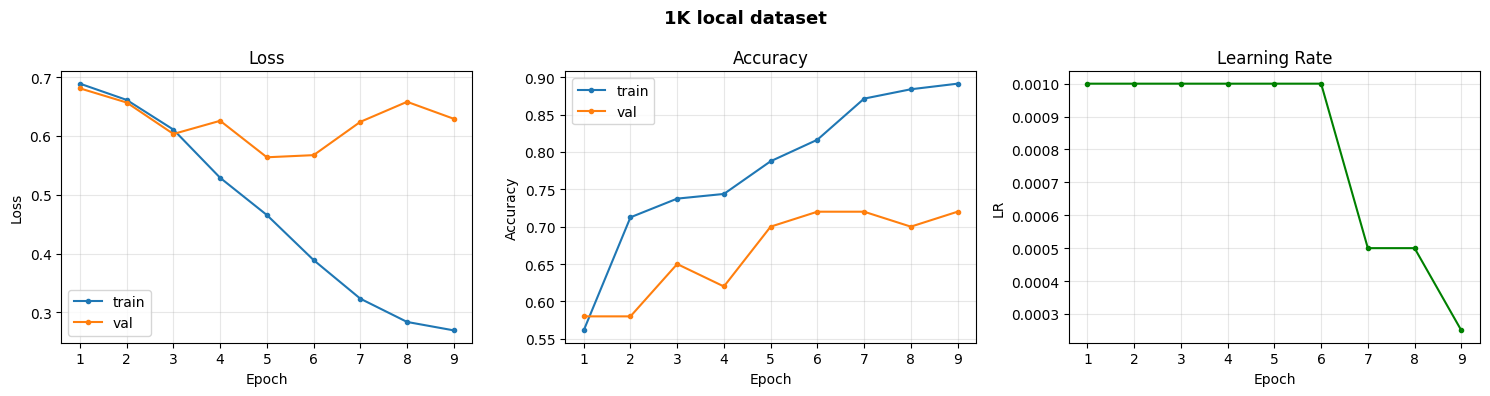

In [7]:
texts_1k, labels_1k = load_local_file("data/amazon_cells_labelled.txt")

# split 80/10/10 same ratios as the shared pipeline
train_t, temp_t, train_l, temp_l = train_test_split(
    texts_1k, labels_1k, test_size=0.2, random_state=SEED, stratify=labels_1k)

val_t, test_t, val_l, test_l = train_test_split(
    temp_t, temp_l, test_size=0.5, random_state=SEED, stratify=temp_l)

splits_1k = {
    "train": {"texts": train_t, "labels": train_l},
    "val":   {"texts": val_t,   "labels": val_l},
    "test":  {"texts": test_t,  "labels": test_l},
}

result_1k = run_experiment("1K local dataset", splits_1k, "bilstm_1k.pt")
all_results.append(result_1k)

## Experiment 2: Medium dataset (25,000 reviews)
Scaling up with the larger local file. 25x more data, should see a solid improvement since the model has way more examples to learn from.


--------------------------------------------------
  25K local dataset
  train=20,000  val=2,500  test=2,500
--------------------------------------------------
Epoch 1/100 (4.9s) | train_loss=0.5194 train_acc=0.7346 | val_loss=0.4239 val_acc=0.8092 | lr=0.001000
  -> saved (val_acc=0.8092)
Epoch 2/100 (5.1s) | train_loss=0.3913 train_acc=0.8231 | val_loss=0.3834 val_acc=0.8264 | lr=0.001000
  -> saved (val_acc=0.8264)
Epoch 3/100 (5.1s) | train_loss=0.3298 train_acc=0.8540 | val_loss=0.3641 val_acc=0.8472 | lr=0.001000
  -> saved (val_acc=0.8472)
Epoch 4/100 (5.1s) | train_loss=0.2855 train_acc=0.8776 | val_loss=0.3625 val_acc=0.8492 | lr=0.001000
  -> saved (val_acc=0.8492)
Epoch 5/100 (5.1s) | train_loss=0.2530 train_acc=0.8925 | val_loss=0.3525 val_acc=0.8648 | lr=0.001000
  -> saved (val_acc=0.8648)
Epoch 6/100 (5.2s) | train_loss=0.2227 train_acc=0.9084 | val_loss=0.3247 val_acc=0.8620 | lr=0.001000
Epoch 7/100 (5.1s) | train_loss=0.1959 train_acc=0.9231 | val_loss=0.3422 val_acc

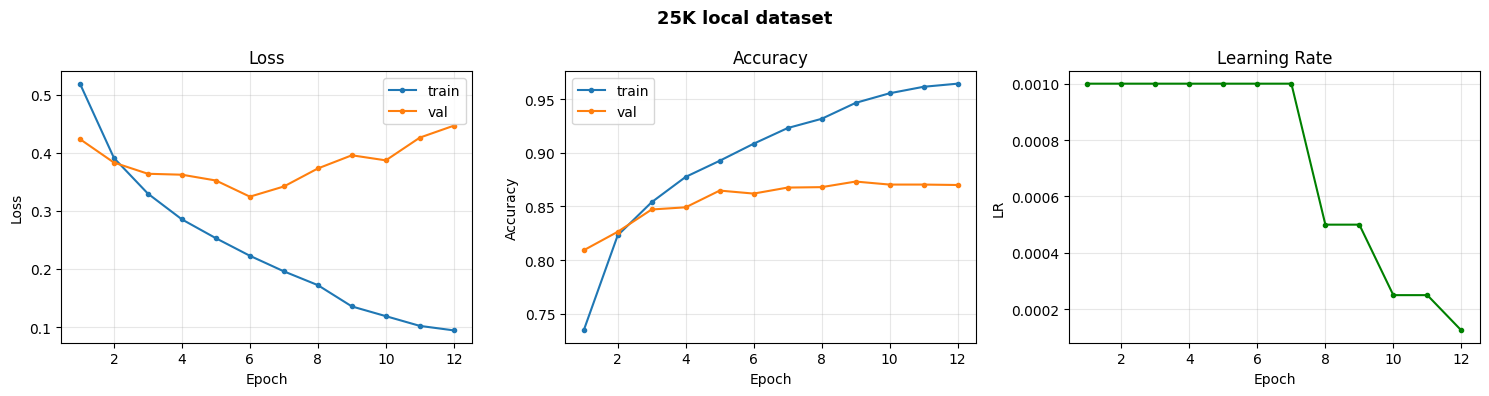

In [8]:
texts_25k, labels_25k = load_local_file("data/amazon_cells_labelled_LARGE_25K.txt")

train_t, temp_t, train_l, temp_l = train_test_split(
    texts_25k, labels_25k, test_size=0.2, random_state=SEED, stratify=labels_25k)

val_t, test_t, val_l, test_l = train_test_split(
    temp_t, temp_l, test_size=0.5, random_state=SEED, stratify=temp_l)

splits_25k = {
    "train": {"texts": train_t, "labels": train_l},
    "val":   {"texts": val_t,   "labels": val_l},
    "test":  {"texts": test_t,  "labels": test_l},
}

result_25k = run_experiment("25K local dataset", splits_25k, "bilstm_25k.pt")
all_results.append(result_25k)

## Experiment 3: Full dataset (3.6M reviews)
Going all in with the complete Amazon Polarity dataset from Hugging Face. This is what we'll use for the final comparison against ANN and Transformer in Task 1.3.


--------------------------------------------------
  Full 3.6M (HF)
  train=2,880,000  val=360,000  test=360,000
--------------------------------------------------
Epoch 1/100 (1268.9s) | train_loss=0.2268 train_acc=0.9072 | val_loss=0.1753 val_acc=0.9321 | lr=0.001000
  -> saved (val_acc=0.9321)
Epoch 2/100 (1278.9s) | train_loss=0.1769 train_acc=0.9314 | val_loss=0.1680 val_acc=0.9363 | lr=0.001000
  -> saved (val_acc=0.9363)
Epoch 3/100 (1290.0s) | train_loss=0.1689 train_acc=0.9350 | val_loss=0.1605 val_acc=0.9387 | lr=0.001000
  -> saved (val_acc=0.9387)
Epoch 4/100 (1268.0s) | train_loss=0.1653 train_acc=0.9365 | val_loss=0.1599 val_acc=0.9385 | lr=0.001000
Epoch 5/100 (1274.1s) | train_loss=0.1631 train_acc=0.9376 | val_loss=0.1586 val_acc=0.9393 | lr=0.001000
  -> saved (val_acc=0.9393)
Epoch 6/100 (1288.8s) | train_loss=0.1619 train_acc=0.9379 | val_loss=0.1551 val_acc=0.9406 | lr=0.001000
  -> saved (val_acc=0.9406)
Epoch 7/100 (1278.9s) | train_loss=0.1612 train_acc=0.9384 

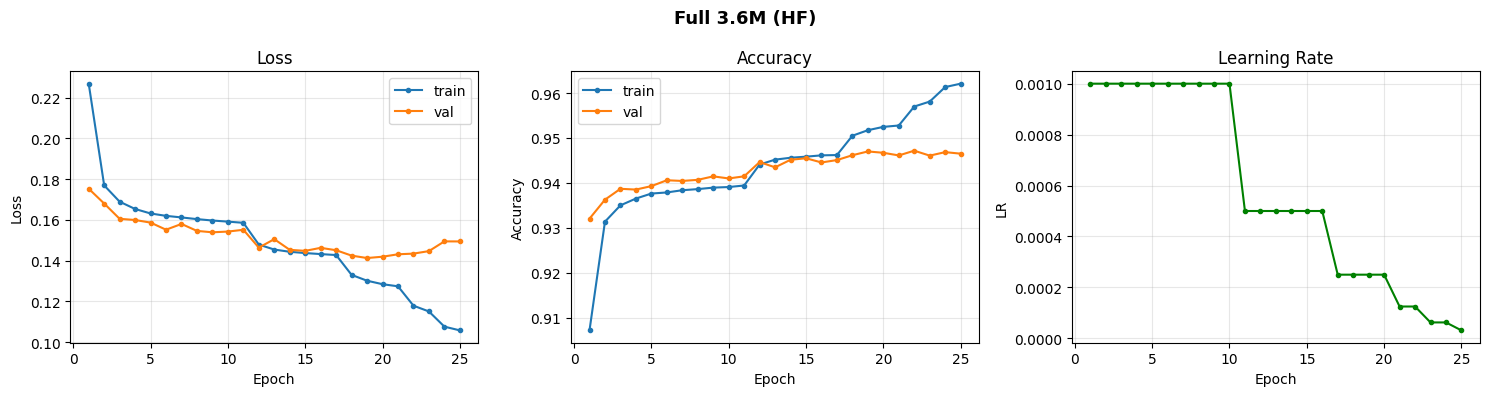

In [9]:
# subset_size=None = full 3.6M reviews
splits_full = load_and_split(subset_size=None)

result_full = run_experiment("Full 3.6M (HF)", splits_full, "best_bilstm.pt")
all_results.append(result_full)

## Data size comparison


Dataset                    Size      Train   Vocab  Epochs  Test Acc      F1
----------------------------------------------------------------------------
1K local dataset          1,000        800   2,142       9    0.7300  0.7429
25K local dataset        25,000     20,000  25,000      12    0.8692  0.8946
Full 3.6M (HF)         3,600,000  2,880,000  25,000      25    0.9472  0.9471


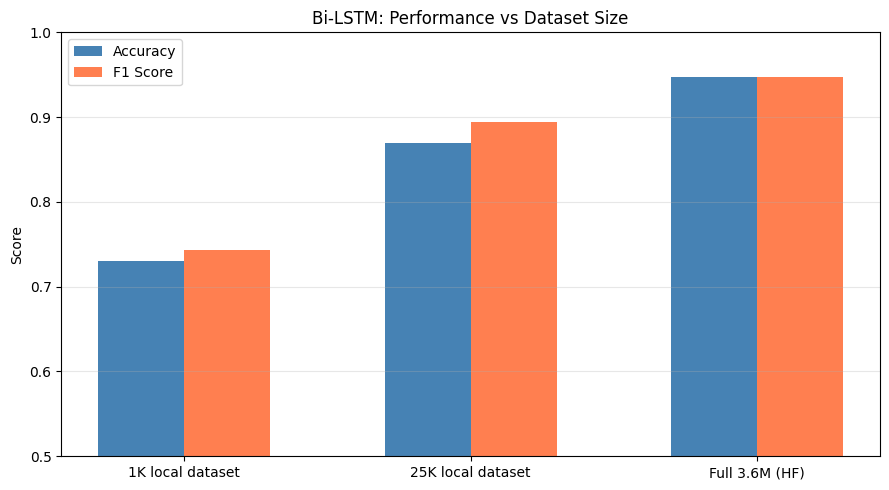

In [10]:
# compare all 3 runs
print(f"\n{'Dataset':<22} {'Size':>8} {'Train':>10} {'Vocab':>7} {'Epochs':>7} {'Test Acc':>9} {'F1':>7}")
print("-" * 76)
for r in all_results:
    print(f"{r['name']:<22} {r['dataset_size']:>8,} {r['train_size']:>10,} "
          f"{r['vocab_size']:>7,} {r['actual_epochs']:>7} {r['test_accuracy']:>9.4f} {r['test_f1']:>7.4f}")

# bar chart
fig, ax = plt.subplots(figsize=(9, 5))
names = [r['name'] for r in all_results]
accs = [r['test_accuracy'] for r in all_results]
f1s = [r['test_f1'] for r in all_results]

x = np.arange(len(names))
w = 0.3
ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
ax.bar(x + w/2, f1s, w, label='F1 Score', color='coral')
ax.set_ylabel('Score')
ax.set_title('Bi-LSTM: Performance vs Dataset Size')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

## Final evaluation (best model)
Loading the best model (full dataset) for the confusion matrix. This is the model we'll use for the Task 1.3 comparison.

Final Test Results (Full 3.6M (HF)):
  Accuracy:  0.9472
  Precision: 0.9481
  Recall:    0.9461
  F1 Score:  0.9471


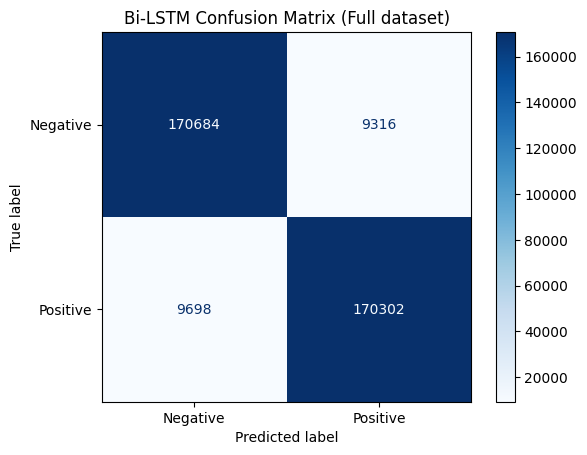

FP: 9,316  FN: 9,698


In [11]:
best = all_results[-1]

print(f"Final Test Results ({best['name']}):")
print(f"  Accuracy:  {best['test_accuracy']:.4f}")
print(f"  Precision: {best['test_precision']:.4f}")
print(f"  Recall:    {best['test_recall']:.4f}")
print(f"  F1 Score:  {best['test_f1']:.4f}")

# confusion matrix
cm = confusion_matrix(best['test_labels'], best['test_preds'])
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Bi-LSTM Confusion Matrix (Full dataset)")
plt.show()

print(f"FP: {cm[0][1]:,}  FN: {cm[1][0]:,}")

## Save results for Task 1.3
Saving the final model's metrics + the data size comparison so the comparison notebook can use it.

In [12]:
best = all_results[-1]

results = {
    "model": "Bi-LSTM",
    "dataset_size": best['dataset_size'],
    "train_size": best['train_size'],
    "vocab_size": best['vocab_size'],
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "total_params": best['total_params'],
    "max_epochs": NUM_EPOCHS,
    "actual_epochs": best['actual_epochs'],
    "early_stopping_patience": PATIENCE,
    "best_val_acc": best['best_val_acc'],
    "test_accuracy": best['test_accuracy'],
    "test_precision": best['test_precision'],
    "test_recall": best['test_recall'],
    "test_f1": best['test_f1'],
    "history": best['history'],
    # also include the data size comparison
    "data_size_comparison": [
        {"name": r['name'], "dataset_size": r['dataset_size'],
         "test_accuracy": r['test_accuracy'], "test_f1": r['test_f1']}
        for r in all_results
    ],
}

with open("bilstm_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("saved to bilstm_results.json")

saved to bilstm_results.json
